In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

## Ajustando a base

In [103]:
print('hello')

hello


In [104]:
df = pd.read_csv('credit_risk_dataset.csv')
print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [105]:
variable_mapping = {
    'person_age': 'idade_individuo',
    'person_income': 'renda_anual_individuo',
    'person_home_ownership': 'tipo_posse_imovel',
    'person_emp_length': 'tempo_emprego_anos',
    'loan_intent': 'proposito_emprestimo',
    'loan_grade': 'classificacao_emprestimo',
    'loan_amnt': 'valor_emprestimo',
    'loan_int_rate': 'taxa_juros_emprestimo',
    'loan_status': 'status_emprestimo',
    'loan_percent_income': 'percentual_renda_emprestimo',
    'cb_person_default_on_file': 'historico_inadimplencia',
    'cb_person_cred_hist_length': 'duracao_historico_credito'
}
df.rename(columns=variable_mapping, inplace=True)
variable_mapping


{'person_age': 'idade_individuo',
 'person_income': 'renda_anual_individuo',
 'person_home_ownership': 'tipo_posse_imovel',
 'person_emp_length': 'tempo_emprego_anos',
 'loan_intent': 'proposito_emprestimo',
 'loan_grade': 'classificacao_emprestimo',
 'loan_amnt': 'valor_emprestimo',
 'loan_int_rate': 'taxa_juros_emprestimo',
 'loan_status': 'status_emprestimo',
 'loan_percent_income': 'percentual_renda_emprestimo',
 'cb_person_default_on_file': 'historico_inadimplencia',
 'cb_person_cred_hist_length': 'duracao_historico_credito'}

In [106]:
# Traduzindo e substituindo as categorias da variável tipo_posse_imovel
mapeamento_categorias_imovel = {
    'RENT': 'aluguel',
    'OWN': 'imovel_proprio',
    'MORTGAGE': 'imovel_financiado',
    'OTHER': 'imovel_outros'
}

df['tipo_posse_imovel'] = df['tipo_posse_imovel'].replace(mapeamento_categorias_imovel)

In [107]:
df['tipo_posse_imovel'].value_counts()

tipo_posse_imovel
aluguel              16446
imovel_financiado    13444
imovel_proprio        2584
imovel_outros          107
Name: count, dtype: int64

In [108]:
# Traduzindo e substituindo as categorias da variável proposito_emprestimo
mapeamento_categorias_proposito = {
    'DEBTCONSOLIDATION': 'fins_consolidacao_debito',
    'EDUCATION': 'fins_educacao',
    'MEDICAL': 'fins_medicos',
    'PERSONAL': 'fins_pessoais',
    'VENTURE': 'fins_negocios',
    'HOMEIMPROVEMENT': 'fins_reformas'
}



df['proposito_emprestimo'] = df['proposito_emprestimo'].replace(mapeamento_categorias_proposito)
df['proposito_emprestimo'].value_counts()

proposito_emprestimo
fins_educacao               6453
fins_medicos                6071
fins_negocios               5719
fins_pessoais               5521
fins_consolidacao_debito    5212
fins_reformas               3605
Name: count, dtype: int64

In [109]:
dict_hist = {
    'N': 'N',
    'Y': 'S'
}

print(df['historico_inadimplencia'].value_counts())
df['historico_inadimplencia'] = df['historico_inadimplencia'].replace(dict_hist)
print(df['historico_inadimplencia'].value_counts())

historico_inadimplencia
N    26836
Y     5745
Name: count, dtype: int64
historico_inadimplencia
N    26836
S     5745
Name: count, dtype: int64


In [110]:
df.head()

,idade_individuo,renda_anual_individuo,tipo_posse_imovel,tempo_emprego_anos,proposito_emprestimo,classificacao_emprestimo,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito
0,22,59000,aluguel,123.0,fins_pessoais,D,35000,16.02,1,0.59,S,3
1,21,9600,imovel_proprio,5.0,fins_educacao,B,1000,11.14,0,0.10,N,2
2,25,9600,imovel_financiado,1.0,fins_medicos,C,5500,12.87,1,0.57,N,3
3,23,65500,aluguel,4.0,fins_medicos,C,35000,15.23,1,0.53,N,2
4,24,54400,aluguel,8.0,fins_medicos,C,35000,14.27,1,0.55,S,4


## Analise Exploratoria de Dados

In [111]:
df = df.reset_index()
df.rename(columns={'index': 'id'}, inplace=True)
df.head()

,id,idade_individuo,renda_anual_individuo,tipo_posse_imovel,tempo_emprego_anos,proposito_emprestimo,classificacao_emprestimo,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito
0,0,22,59000,aluguel,123.0,fins_pessoais,D,35000,16.02,1,0.59,S,3
1,1,21,9600,imovel_proprio,5.0,fins_educacao,B,1000,11.14,0,0.10,N,2
2,2,25,9600,imovel_financiado,1.0,fins_medicos,C,5500,12.87,1,0.57,N,3
3,3,23,65500,aluguel,4.0,fins_medicos,C,35000,15.23,1,0.53,N,2
4,4,24,54400,aluguel,8.0,fins_medicos,C,35000,14.27,1,0.55,S,4


In [117]:
df_agp = df.groupby('classificacao_emprestimo').agg({'status_emprestimo': 'sum', 'id': 'count'})
df_agp['perc_default'] =  df_agp['status_emprestimo'] / df_agp['id']
df_agp = df_agp.reset_index()
df_agp

,classificacao_emprestimo,status_emprestimo,id,perc_default
0,A,1073,10777,0.099564
1,B,1701,10451,0.162760
2,C,1339,6458,0.207340
3,D,2141,3626,0.590458
4,E,621,964,0.644191
5,F,170,241,0.705394
6,G,63,64,0.984375


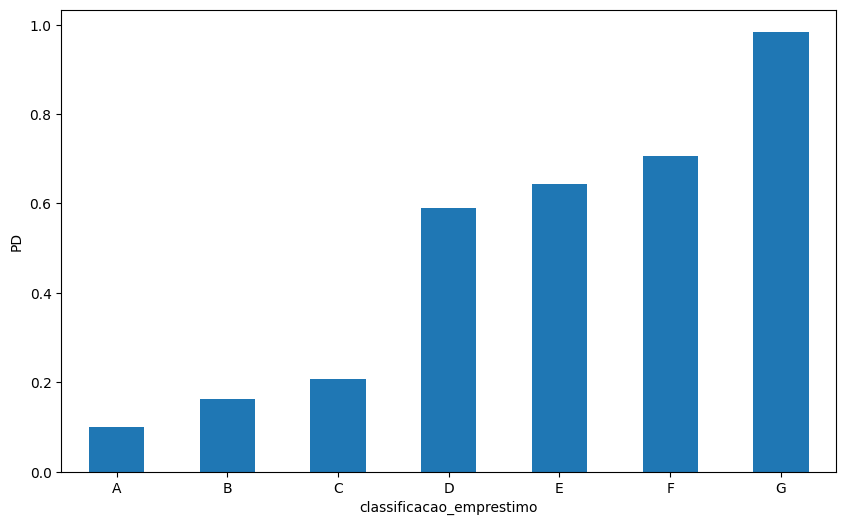

In [133]:
ax = df_agp.plot(x='classificacao_emprestimo', 
                 y='perc_default', 
                 kind='bar',
                 figsize=(10,6), 
                 legend=False)
ax.set_ylabel('PD')
ax.tick_params(axis='x', rotation=0)
plt.show()